<a href="https://colab.research.google.com/github/rifkihariyanto25/Machine-Learning-Dicoding/blob/main/Membangun_Proyek_Machine_Learning_Dicoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KRITERIA 1: MEMUAT DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/onlinefraud.csv')

# head()
print("=== HEAD ===")
df.head()

=== HEAD ===


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [2]:
# info()
print("=== INFO ===")
df.info()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42271 entries, 0 to 42270
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            42271 non-null  int64  
 1   type            42271 non-null  object 
 2   amount          42271 non-null  float64
 3   nameOrig        42271 non-null  object 
 4   oldbalanceOrg   42271 non-null  float64
 5   newbalanceOrig  42271 non-null  float64
 6   nameDest        42271 non-null  object 
 7   oldbalanceDest  42270 non-null  float64
 8   newbalanceDest  42270 non-null  float64
 9   isFraud         42270 non-null  float64
 10  isFlaggedFraud  42270 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 3.5+ MB


In [3]:
# describe()
print("=== DESCRIBE ===")
df.describe()

=== DESCRIBE ===


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,42271.000000,4.227100e+04,4.227100e+04,4.227100e+04,4.227000e+04,4.227000e+04,42270.000000,42270.0
mean,7.171087,1.490108e+05,7.727734e+05,7.874065e+05,8.450982e+05,1.158405e+06,0.002224,0.0
std,2.118037,3.145005e+05,2.284003e+06,2.321941e+06,2.466743e+06,2.960508e+06,0.047105,0.0
min,1.000000,1.770000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,7.000000,7.031875e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,8.000000,2.751283e+04,1.856733e+04,3.339900e+02,0.000000e+00,0.000000e+00,0.000000,0.0
75%,8.000000,1.794321e+05,1.421965e+05,1.500335e+05,4.337969e+05,8.013660e+05,0.000000,0.0
max,9.000000,1.000000e+07,2.854724e+07,2.861740e+07,2.958454e+07,3.130692e+07,1.000000,0.0


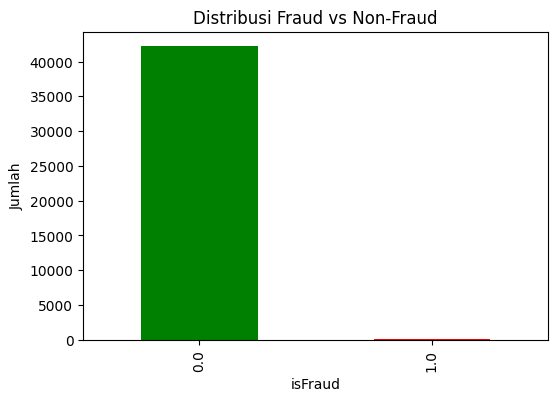

In [4]:
# Visualisasi distribusi fraud
plt.figure(figsize=(6,4))
df['isFraud'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Distribusi Fraud vs Non-Fraud')
plt.xlabel('isFraud')
plt.ylabel('Jumlah')
plt.show()

# KRITERIA 2: PEMBERSIHAN DAN PRA PEMROSESAN DATA

In [5]:

# Cek missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64


In [6]:
# Cek duplikat
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


In [7]:
# Hapus missing values dan duplikat
df = df.dropna()
df = df.drop_duplicates()

# Drop kolom ID
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

print("Shape setelah cleaning:", df.shape)
df.head()

Shape setelah cleaning: (42270, 8)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0


In [8]:
# Label Encoding untuk kolom kategorikal
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

print("Setelah encoding:")
df.head()

Setelah encoding:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0


# KRITERIA 3: MEMBANGUN MODEL CLUSTERING

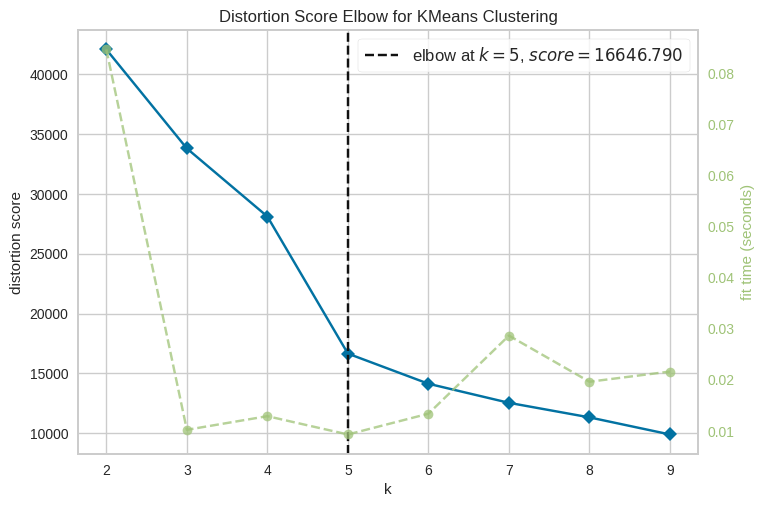

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import joblib

# Ambil sample 10.000 data agar lebih cepat
df_sample = df.sample(10000, random_state=42)

# Pilih fitur untuk clustering
features = ['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest']
X = df_sample[features]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
model_kmeans = KMeans(random_state=42)
visualizer = KElbowVisualizer(model_kmeans, k=(2,10))
visualizer.fit(X_scaled)
visualizer.show()

In [10]:
# Training K-Means dengan k optimal
optimal_k = visualizer.elbow_value_
print(f"Optimal K: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)

# Simpan model clustering (NAMA HARUS PERSIS INI!)
joblib.dump(kmeans, 'model_clustering')
print("Model clustering tersimpan!")

Optimal K: 5
Model clustering tersimpan!


# KRITERIA 4: INTERPRETASI HASIL CLUSTERING

In [11]:

# Tambah hasil cluster ke dataframe
df_sample = df_sample.copy()
df_sample['Target'] = kmeans.labels_

# Analisis deskriptif per cluster
print("=== Analisis Mean, Min, Max per Cluster ===")
cluster_analysis = df_sample.groupby('Target')[features].agg(['mean', 'min', 'max'])
print(cluster_analysis)

=== Analisis Mean, Min, Max per Cluster ===
            type                amount                        oldbalanceOrg  \
            mean min max          mean        min         max          mean   
Target                                                                        
0       3.078641   2   4  3.669401e+04       4.36   783104.02  1.184879e+05   
1       0.698052   0   2  1.747339e+05     272.59   963532.14  4.214483e+05   
2       1.238482   0   4  3.575207e+05     816.88  3007043.04  1.470546e+06   
3       3.990741   1   4  1.409269e+06  531592.87  3989315.70  9.584923e+04   
4       0.064706   0   4  1.571983e+05     783.31   920773.86  7.818361e+06   

                                newbalanceOrig                           \
               min          max           mean         min          max   
Target                                                                    
0             0.00   5334735.48   1.100745e+05        0.00   5292599.20   
1             0.00   40

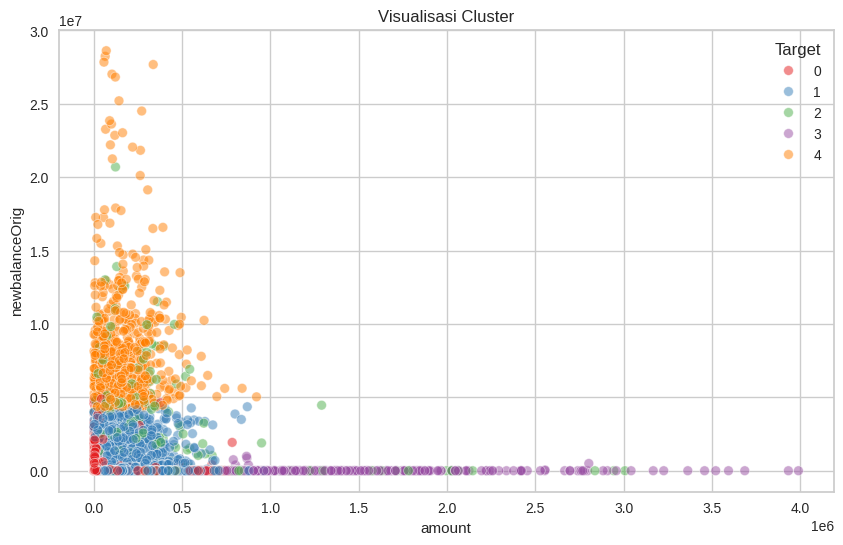

In [12]:
# Visualisasi cluster
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_sample, x='amount', y='newbalanceOrig',
                hue='Target', palette='Set1', alpha=0.5)
plt.title('Visualisasi Cluster')
plt.show()

In [13]:
# Jelaskan karakteristik tiap cluster
for cluster in range(optimal_k):
    print(f"\n=== Cluster {cluster} ===")
    cluster_data = df_sample[df_sample['Target'] == cluster]
    print(f"Jumlah data: {len(cluster_data)}")
    print(f"Rata-rata amount: {cluster_data['amount'].mean():.2f}")
    print(f"Jumlah fraud: {cluster_data['isFraud'].sum()}")

# Export data dengan kolom Target
df_sample.to_csv('data_clustering.csv', index=False)
print("\nData berhasil diekspor!")
df_sample.head()


=== Cluster 0 ===
Jumlah data: 5239
Rata-rata amount: 36694.01
Jumlah fraud: 12.0

=== Cluster 1 ===
Jumlah data: 3388
Rata-rata amount: 174733.89
Jumlah fraud: 18.0

=== Cluster 2 ===
Jumlah data: 369
Rata-rata amount: 357520.67
Jumlah fraud: 0.0

=== Cluster 3 ===
Jumlah data: 324
Rata-rata amount: 1409269.29
Jumlah fraud: 1.0

=== Cluster 4 ===
Jumlah data: 680
Rata-rata amount: 157198.33
Jumlah fraud: 0.0

Data berhasil diekspor!


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,Target
8602,7,0,184246.71,7046810.77,7231057.48,215691.41,31444.7,0.0,4
31925,8,3,9319.16,26306.00,16986.84,0.00,0.0,0.0,0
29572,8,3,991.66,672204.00,671212.35,0.00,0.0,0.0,0
3154,2,3,473.51,20452.00,19978.49,0.00,0.0,0.0,0
38214,9,0,229126.40,61281.00,290407.40,14455.00,0.0,0.0,1


# KRITERIA 5: MEMBANGUN MODEL KLASIFIKASI

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Siapkan fitur dan target
X_clf = df_sample[features]
y_clf = df_sample['Target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Training: {X_train.shape}, Testing: {X_test.shape}")

Training: (8000, 6), Testing: (2000, 6)


In [15]:
# Bangun Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

# Evaluasi
y_pred = dt.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9905

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1047
           1       0.99      0.99      0.99       644
           2       0.99      0.90      0.94        84
           3       0.97      0.93      0.95        74
           4       0.98      0.99      0.98       151

    accuracy                           0.99      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.99      0.99      0.99      2000



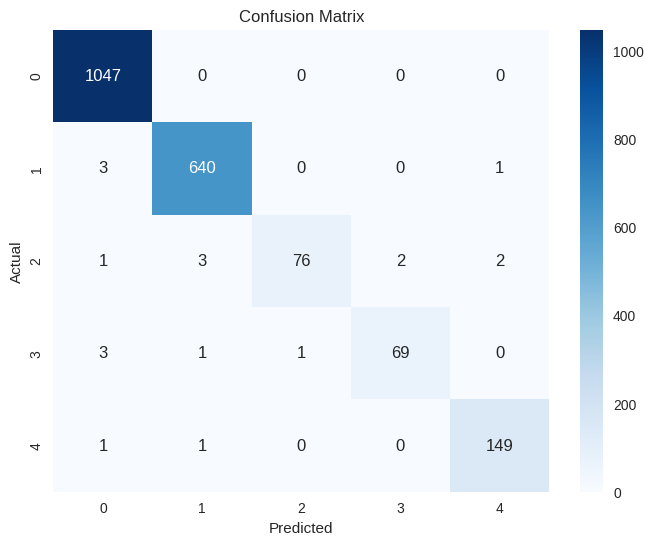

Model klasifikasi tersimpan!


In [16]:
# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Simpan model
joblib.dump(dt, 'decision_tree_model.h5')
print("Model klasifikasi tersimpan!")

In [17]:
import shutil
import os

# Pastikan semua file ada
files = ['model_clustering', 'decision_tree_model.h5', 'data_clustering.csv']
for f in files:
    print(f"{f}: {'✅ Ada' if os.path.exists(f) else '❌ Tidak ada'}")

# Buat ZIP
shutil.make_archive('submission_proyek_ML', 'zip', '/content/')
print("ZIP berhasil dibuat!")

model_clustering: ✅ Ada
decision_tree_model.h5: ✅ Ada
data_clustering.csv: ✅ Ada
ZIP berhasil dibuat!
